In [95]:
#EDA Assignment
#KARTHIKEIN MR
#C72 BATCH
#DATE-03/DEC/2024

In [75]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [76]:
# Configurations
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
%matplotlib inline

In [77]:
# Load datasets
application_data = pd.read_csv('application_data.csv')
previous_application_data = pd.read_csv('previous_application.csv')

In [78]:
from IPython.display import display

# application_data
print("Application Data (First 5 Rows):")
display(application_data.head())

# previous_application_data
print("\nPrevious Application Data (First 5 Rows):")
display(previous_application_data.head())


Application Data (First 5 Rows):


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Previous Application Data (First 5 Rows):


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Remove columns containing the"flag" from both datasets
flag_columns_application = [col for col in application_data.columns if 'flag' in col.lower()]
flag_columns_previous = [col for col in previous_application_data.columns if 'flag' in col.lower()]

# Count removed columns
removed_count_application = len(flag_columns_application)
removed_count_previous = len(flag_columns_previous)

# Drop the flag columns
application_data = application_data.drop(columns=flag_columns_application)
previous_application_data = previous_application_data.drop(columns=flag_columns_previous)
print(f"\nNumber of removed columns from application_data: {removed_count_application}")
print(f"Number of removed columns from previous_application_data: {removed_count_previous}")


Number of removed columns from application_data: 28
Number of removed columns from previous_application_data: 3


In [80]:
# shapes of the datasets
print(f"Application Data Shape: {application_data.shape}")
print(f"Previous Application Data Shape: {previous_application_data.shape}")

Application Data Shape: (307511, 94)
Previous Application Data Shape: (1670214, 34)


In [81]:
from IPython.display import display

# application_data after data cleaning
print("Application Data (First 5 Rows):")
display(application_data.head())

# previous_application after data cleaning
print("\nPrevious Application Data (First 5 Rows):")
display(previous_application_data.head())


Application Data (First 5 Rows):


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,2.0,2.0,2.0,-1134.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,0.0,1.0,0.0,-828.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0.0,0.0,0.0,-815.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,0.0,2.0,0.0,-617.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0.0,0.0,0.0,-1106.0,0.0,0.0,0.0,0.0,0.0,0.0



Previous Application Data (First 5 Rows):


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN


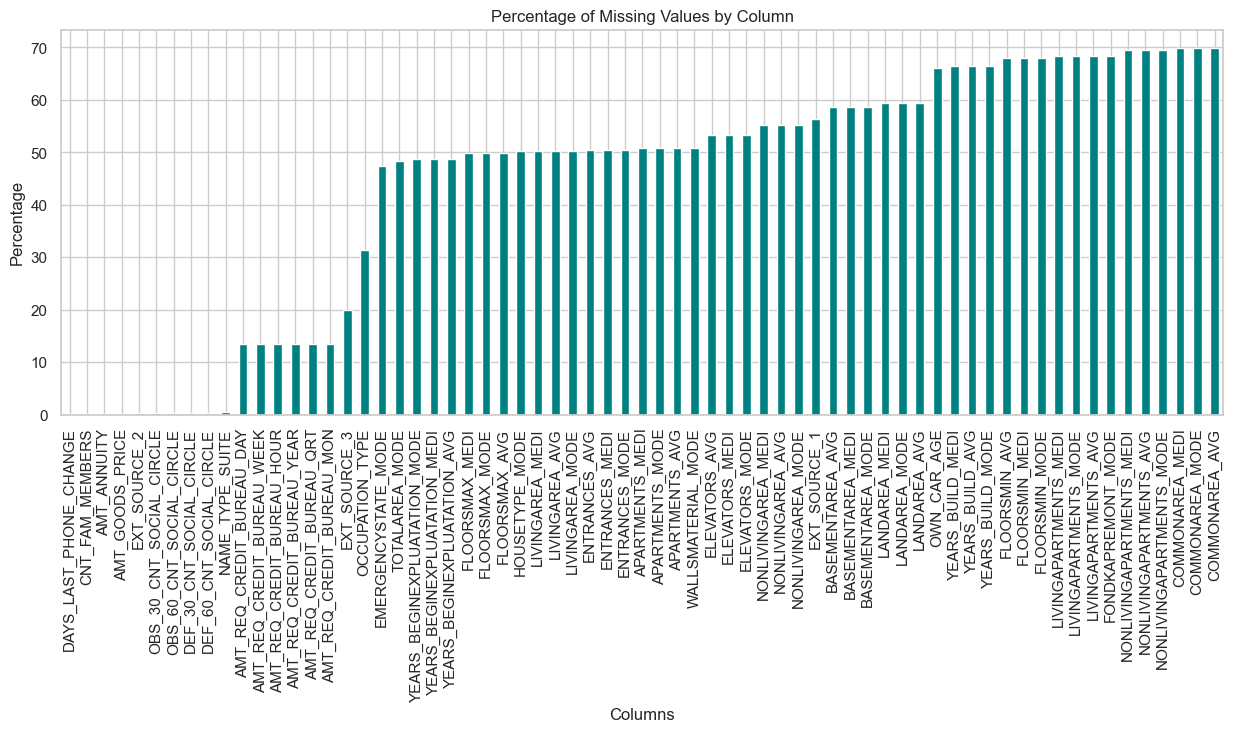

In [82]:
# Detect and visualize missing values
missing_values = application_data.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values()
plt.figure(figsize=(15, 5))
missing_values.plot(kind='bar', color='teal')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.xlabel('Columns')
plt.savefig('missing_values_plot.png',dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

# Remove columns with greater than 20% missing values
application_data = application_data.loc[:, application_data.isnull().mean() <= 0.2]
previous_application_data = previous_application_data.loc[:, previous_application_data.isnull().mean() <= 0.2]

# Fill missing values for numerical columns with median and mode
numeric_cols = application_data.select_dtypes(include=np.number).columns
application_data[numeric_cols] = application_data[numeric_cols].fillna(application_data[numeric_cols].median())
categorical_cols = application_data.select_dtypes(include='object').columns
for col in categorical_cols:
    application_data[col].fillna(application_data[col].mode()[0], inplace=True)

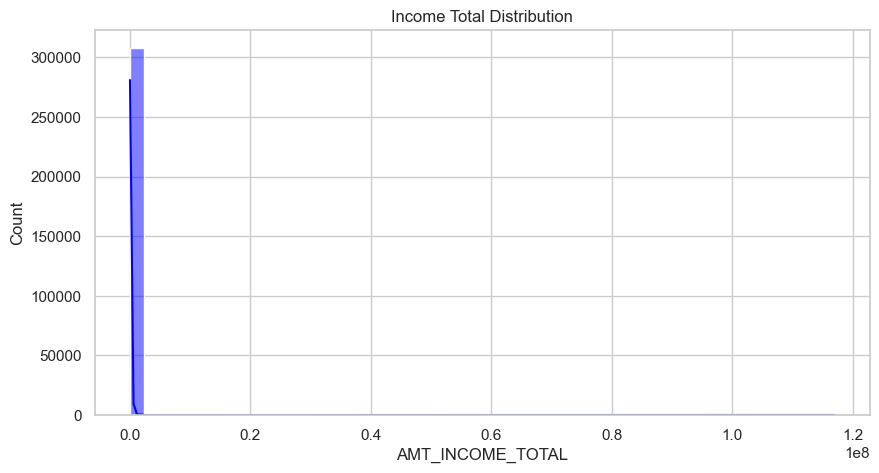

In [83]:
# Univariate analysis - Income Total
plt.figure(figsize=(10, 5))
sns.histplot(application_data['AMT_INCOME_TOTAL'], bins=50, kde=True, color='blue')
plt.title('Income Total Distribution')
plt.savefig('income_distribution.png',dpi=300, bbox_inches='tight') # saving img for ppt
plt.show()

In [84]:
# Outlier handling for 'AMT_INCOME_TOTAL'
Q1 = application_data['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = application_data['AMT_INCOME_TOTAL'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
application_data = application_data[(application_data['AMT_INCOME_TOTAL'] >= lower_bound) & (application_data['AMT_INCOME_TOTAL'] <= upper_bound)]

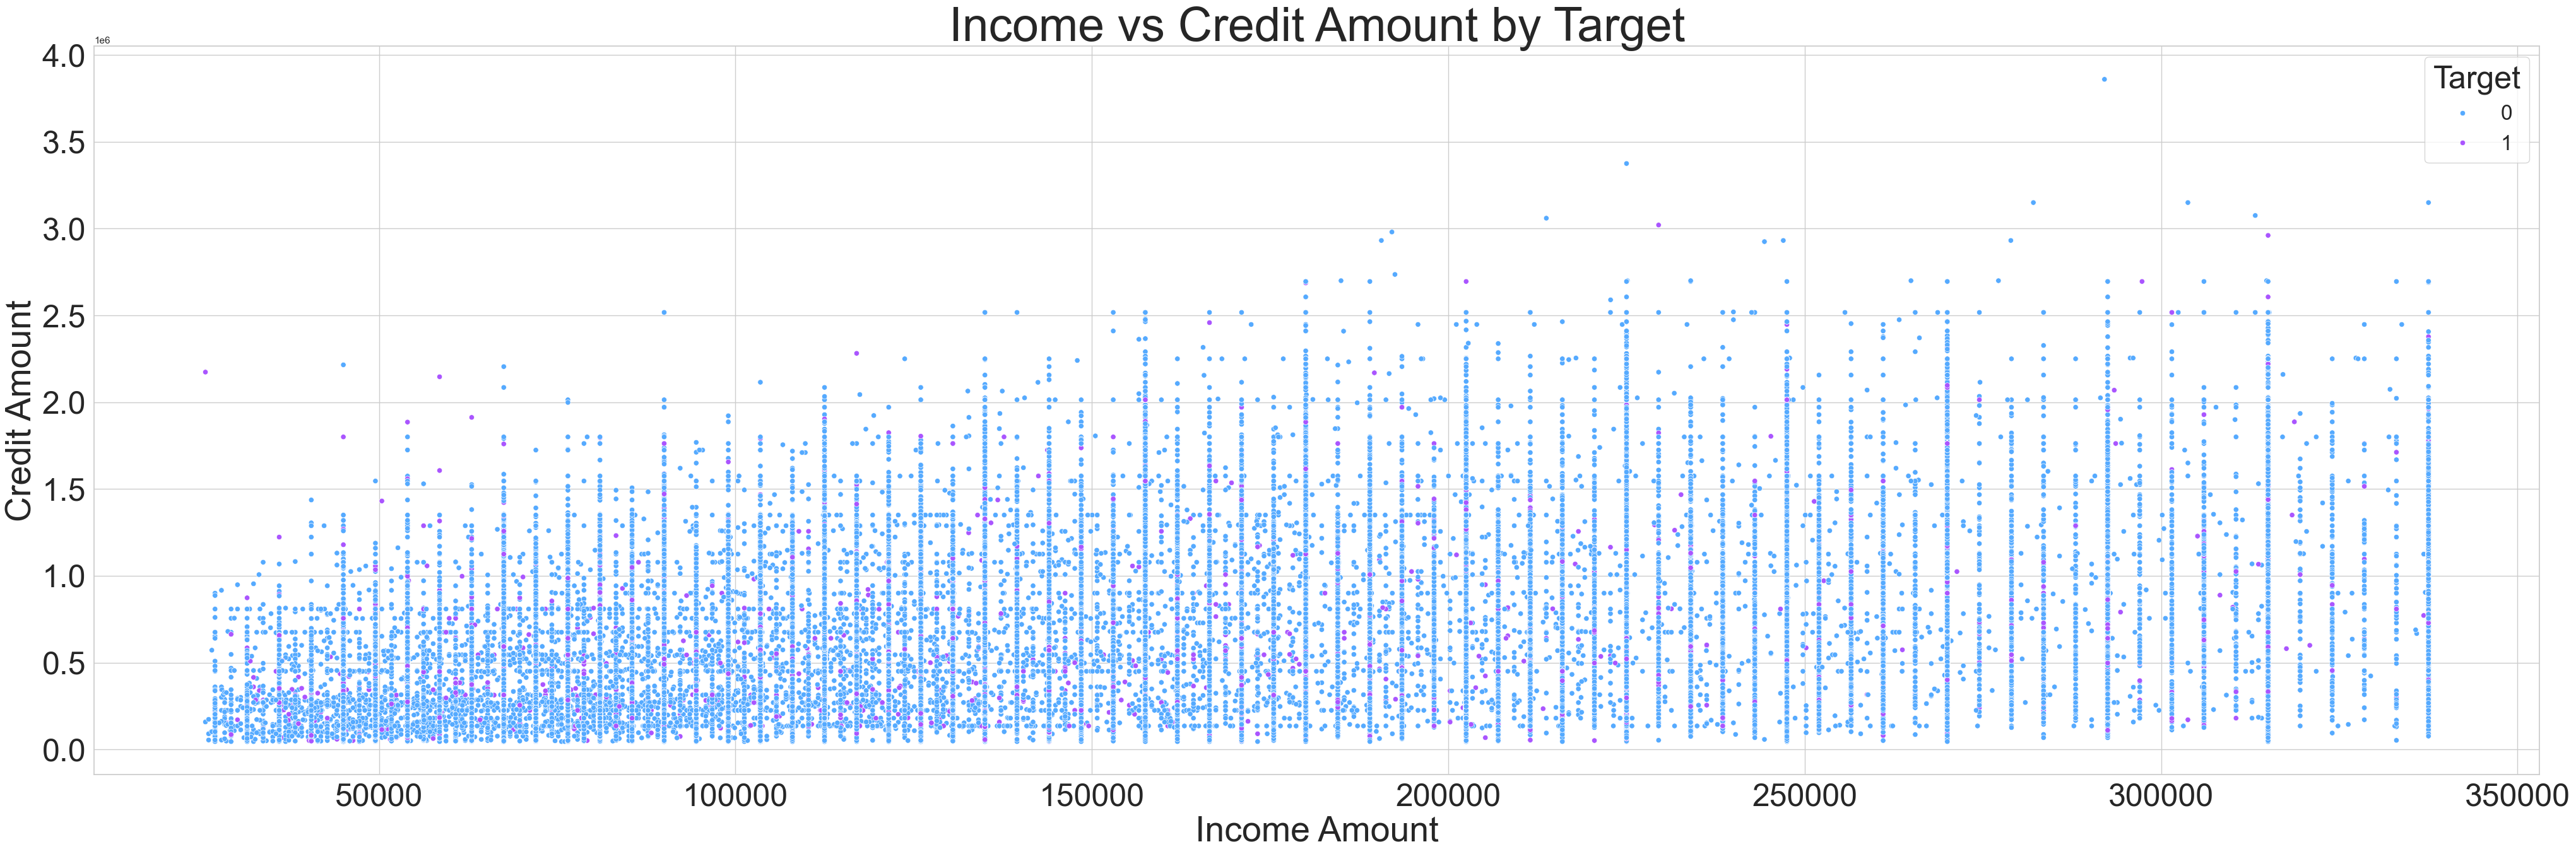

In [85]:
# Bivariate analysis: Income vs Credit
plt.figure(figsize=(50, 15))
sns.scatterplot(x='AMT_INCOME_TOTAL', 
                y='AMT_CREDIT', 
                hue='TARGET', 
                data=application_data, 
                palette='cool')
plt.title('Income vs Credit Amount by Target', fontsize=54) 
plt.xlabel('Income Amount', fontsize=40) 
plt.ylabel('Credit Amount', fontsize=40)  
plt.xticks(fontsize=36)  
plt.yticks(fontsize=36)  
plt.legend(title='Target', title_fontsize=36, fontsize=24) 
plt.savefig('income_vs_credit.png',dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

In [86]:
# Splitting the data by target variable
default_clients = application_data[application_data['TARGET'] == 1]
non_default_clients = application_data[application_data['TARGET'] == 0]

Top 10 correlations for Default Clients:
OBS_30_CNT_SOCIAL_CIRCLE    OBS_60_CNT_SOCIAL_CIRCLE       0.998240
AMT_CREDIT                  AMT_GOODS_PRICE                0.981995
REGION_RATING_CLIENT        REGION_RATING_CLIENT_W_CITY    0.957935
CNT_CHILDREN                CNT_FAM_MEMBERS                0.885157
DEF_30_CNT_SOCIAL_CIRCLE    DEF_60_CNT_SOCIAL_CIRCLE       0.869035
REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION    0.849556
REG_CITY_NOT_WORK_CITY      LIVE_CITY_NOT_WORK_CITY        0.777738
AMT_CREDIT                  AMT_ANNUITY                    0.750779
AMT_ANNUITY                 AMT_GOODS_PRICE                0.749910
REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION     0.494870
dtype: float64


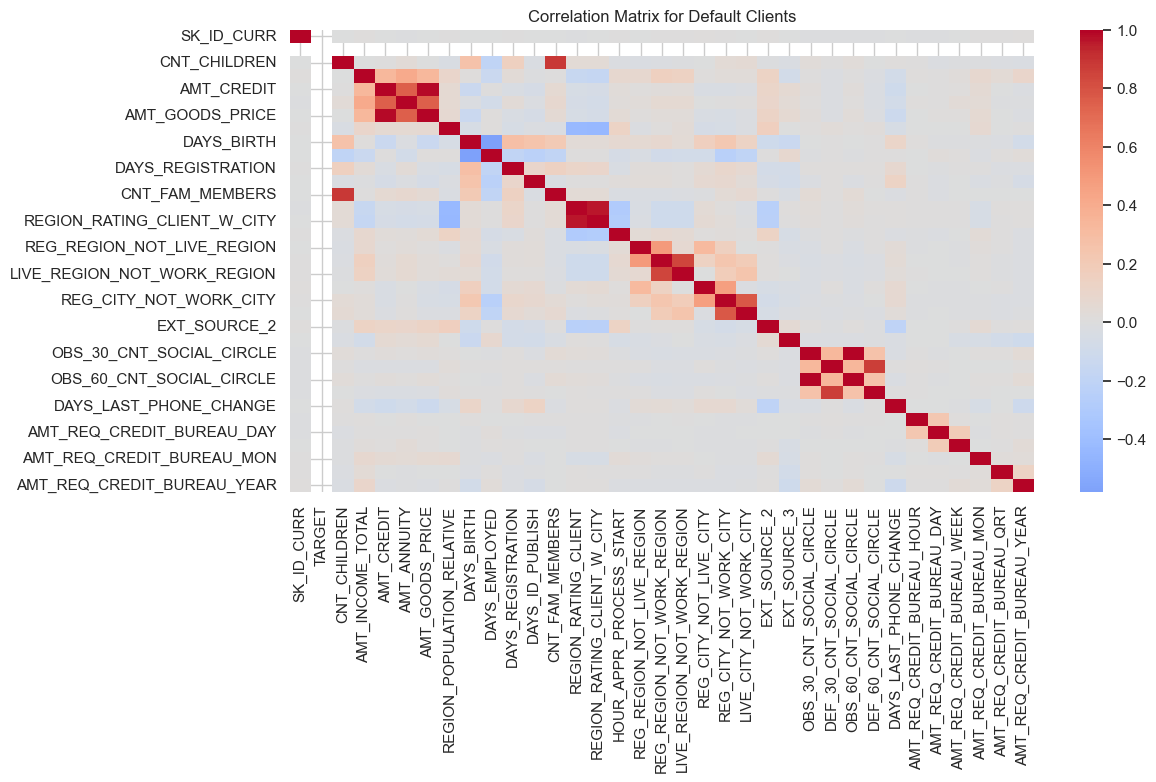

In [87]:
# numeric columns for default clients
numeric_default_clients = default_clients.select_dtypes(include=np.number)
corr_matrix_default = numeric_default_clients.corr()
# top 10 correlations for Default Clients
top_corr_default = (corr_matrix_default.where(np.triu(np.ones(corr_matrix_default.shape), k=1).astype(bool))
.stack()
.sort_values(ascending=False))
print("Top 10 correlations for Default Clients:")
print(top_corr_default.head(10))
# Correlation visualization
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix_default, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Default Clients')
plt.savefig('correlation_default_clients.png',dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

Top 10 correlations for Non-Default Clients:
OBS_30_CNT_SOCIAL_CIRCLE    OBS_60_CNT_SOCIAL_CIRCLE       0.998513
AMT_CREDIT                  AMT_GOODS_PRICE                0.986335
REGION_RATING_CLIENT        REGION_RATING_CLIENT_W_CITY    0.950005
CNT_CHILDREN                CNT_FAM_MEMBERS                0.877668
REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION    0.861797
DEF_30_CNT_SOCIAL_CIRCLE    DEF_60_CNT_SOCIAL_CIRCLE       0.860208
REG_CITY_NOT_WORK_CITY      LIVE_CITY_NOT_WORK_CITY        0.829976
AMT_ANNUITY                 AMT_GOODS_PRICE                0.777427
AMT_CREDIT                  AMT_ANNUITY                    0.775064
REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION     0.449456
dtype: float64


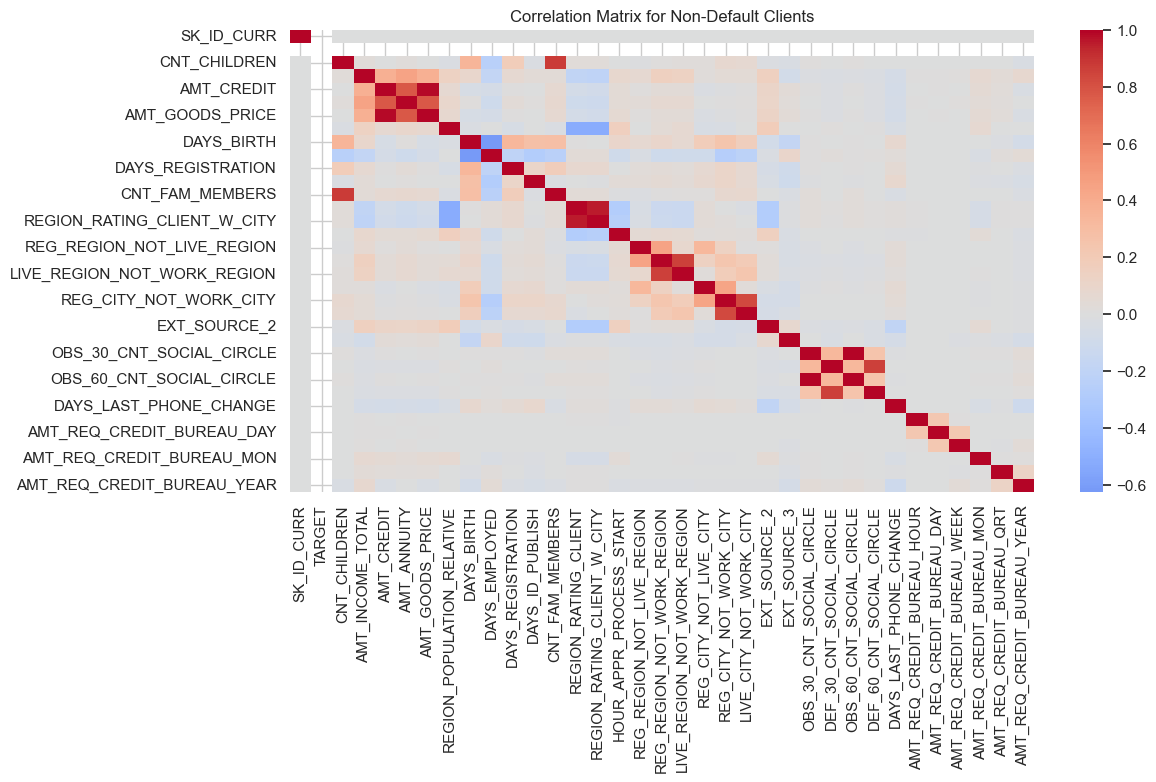

In [88]:
# numeric columns for non-default clients
numeric_non_default_clients = non_default_clients.select_dtypes(include=np.number)
corr_matrix_non_default = numeric_non_default_clients.corr()

# Get top correlations for non-default clients 
top_corr_non_default = ( corr_matrix_non_default.where(np.triu(np.ones(corr_matrix_non_default.shape), k=1).astype(bool))
.stack()
.sort_values(ascending=False))

# top 10 correlations for Non-Default Clients
print("Top 10 correlations for Non-Default Clients:")
print(top_corr_non_default.head(10))
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix_non_default, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Non-Default Clients')
plt.savefig('correlation_non_default_clients.png',dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

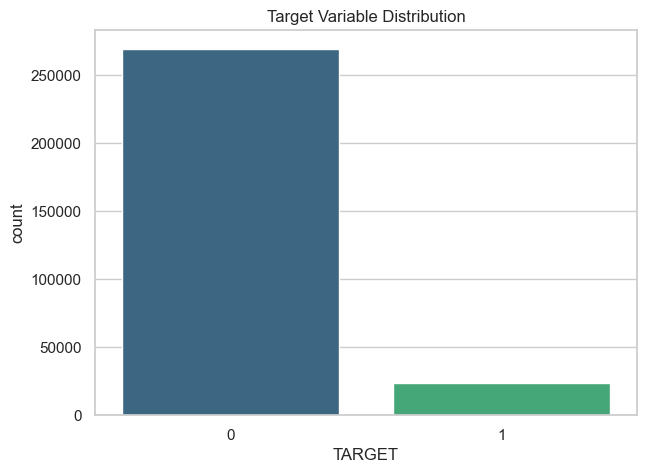

In [89]:
# Target variable distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='TARGET', data=application_data, palette='viridis')
plt.title('Target Variable Distribution')
plt.savefig('target_variable_distribution.png', dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

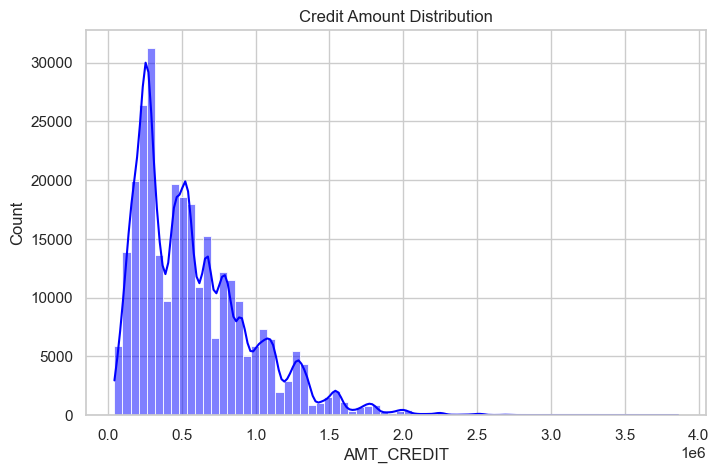

In [90]:
# Numerical variable: Credit Distribution
plt.figure(figsize=(8, 5))
sns.histplot(application_data['AMT_CREDIT'], bins=70,kde=True,color='blue')
plt.title('Credit Amount Distribution')
plt.savefig('credit_amount_distribution.png', dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

In [91]:
# Income ranges
bins_income = [0, 25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000, 250000, 1e10]
labels_income = ['0-25k', '25k-50k', '50k-75k', '75k-100k', '100k-125k', '125k-150k', '150k-175k', '175k-200k', '200k-250k', '250k+']

application_data['AMT_INCOME_RANGE'] = pd.cut(application_data['AMT_INCOME_TOTAL'], bins=bins_income, labels=labels_income)

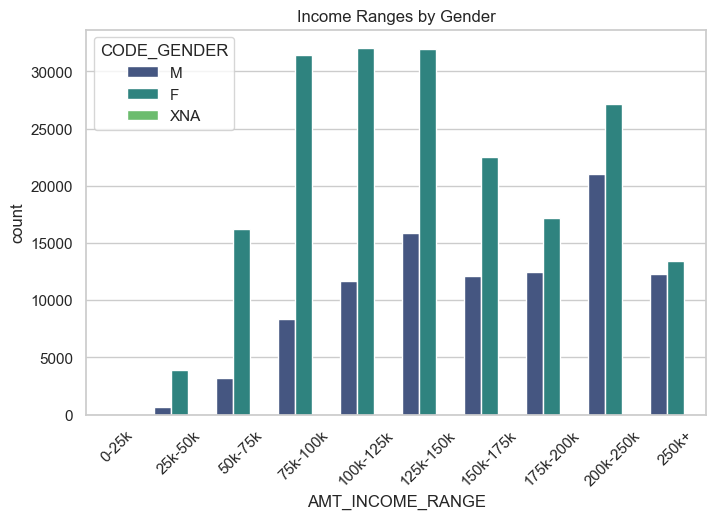

In [92]:
# Income range by target and gender
plt.figure(figsize=(8, 5))
sns.countplot(data=application_data, x='AMT_INCOME_RANGE', hue='CODE_GENDER', palette='viridis')
plt.xticks(rotation=(45))
plt.title('Income Ranges by Gender')
plt.savefig('income_ranges_by_gender.png', dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()

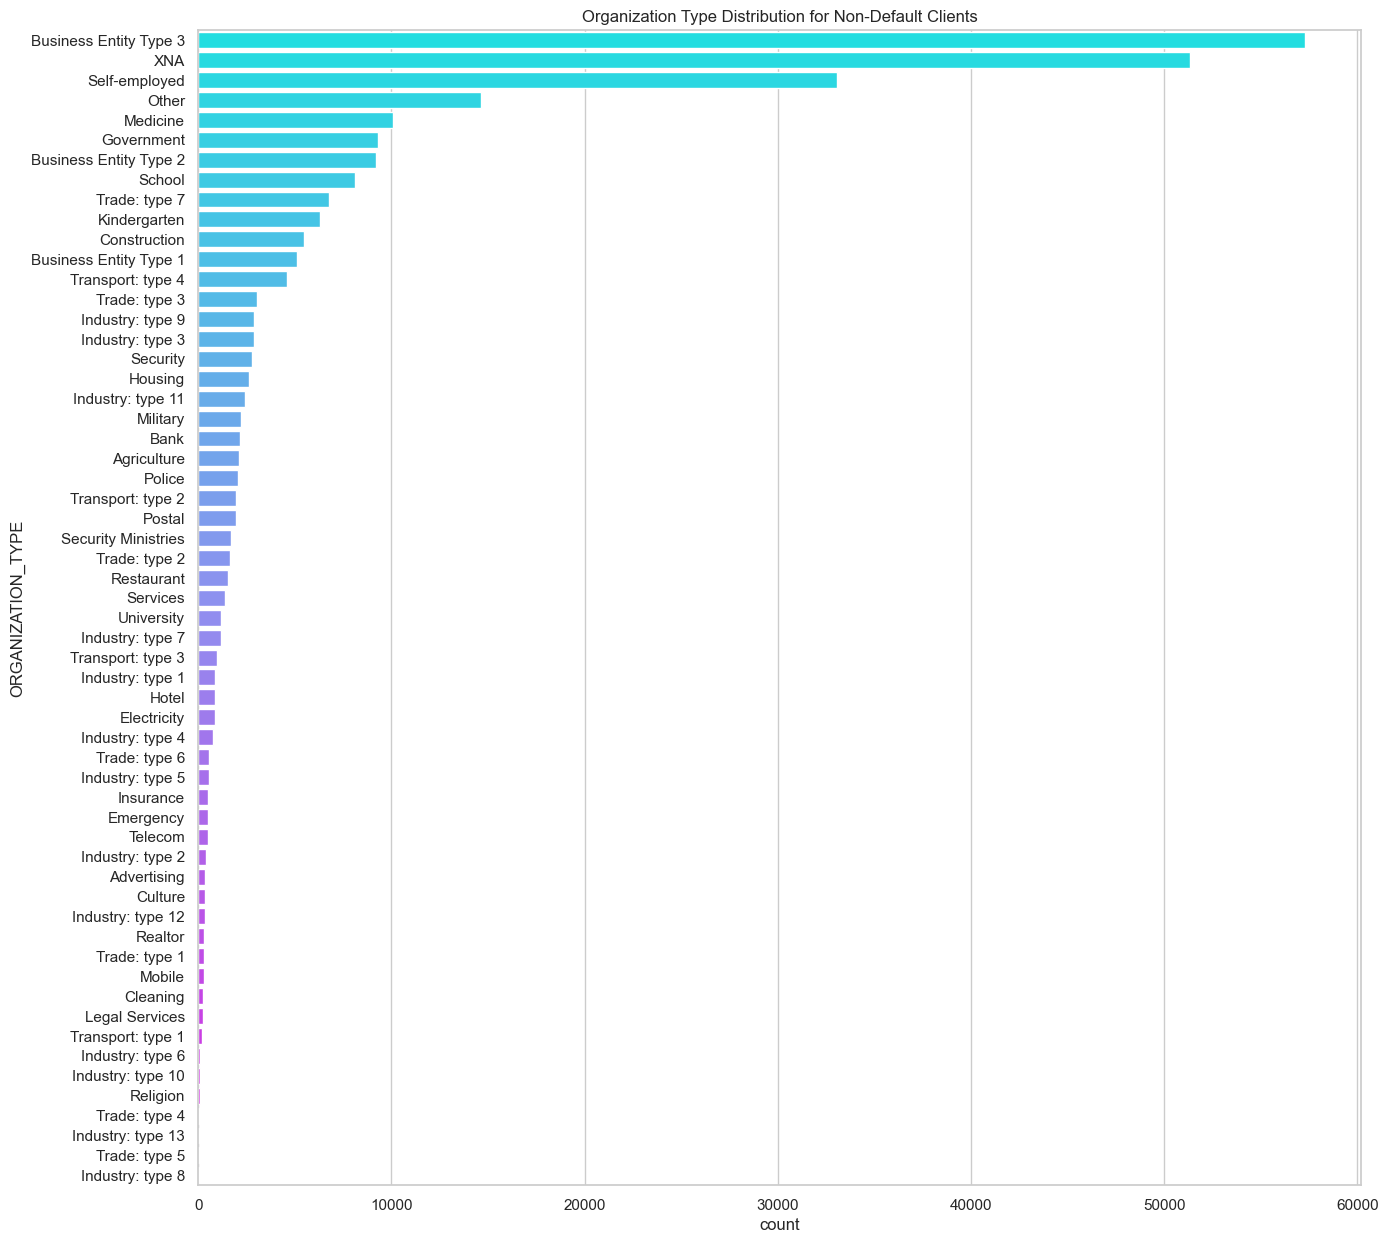

In [93]:
# Organization type for non-default clients
plt.figure(figsize=(15, 15))
sns.countplot(data=non_default_clients, y='ORGANIZATION_TYPE', order=non_default_clients['ORGANIZATION_TYPE'].value_counts().index, palette='cool')
plt.title('Organization Type Distribution for Non-Default Clients')
plt.savefig('organization_type_distribution_non_default_clients.png', dpi=300, bbox_inches='tight')# saving img for ppt
plt.show()